In [1]:
import numpy as np
from sklearn import datasets
from sklearn.svm import SVC

In [2]:
X, Y = datasets.make_blobs(
    n_samples=100,
    cluster_std=1.1,
    random_state=42,
    centers=2
)

In [26]:
svm = SVC(kernel='linear', C=10)
svm.fit(X, Y)

w = svm.coef_[0]
b = svm.intercept_

def decision_line(x):
    return -(w[0]*x + b) / w[1]

x_vals = np.linspace(X[:,0].min(), X[:,0].max(), 100)
x_vals

array([-5.39091724, -5.26863844, -5.14635965, -5.02408086, -4.90180206,
       -4.77952327, -4.65724448, -4.53496568, -4.41268689, -4.2904081 ,
       -4.1681293 , -4.04585051, -3.92357171, -3.80129292, -3.67901413,
       -3.55673533, -3.43445654, -3.31217775, -3.18989895, -3.06762016,
       -2.94534137, -2.82306257, -2.70078378, -2.57850499, -2.45622619,
       -2.3339474 , -2.2116686 , -2.08938981, -1.96711102, -1.84483222,
       -1.72255343, -1.60027464, -1.47799584, -1.35571705, -1.23343826,
       -1.11115946, -0.98888067, -0.86660187, -0.74432308, -0.62204429,
       -0.49976549, -0.3774867 , -0.25520791, -0.13292911, -0.01065032,
        0.11162847,  0.23390727,  0.35618606,  0.47846485,  0.60074365,
        0.72302244,  0.84530124,  0.96758003,  1.08985882,  1.21213762,
        1.33441641,  1.4566952 ,  1.578974  ,  1.70125279,  1.82353158,
        1.94581038,  2.06808917,  2.19036796,  2.31264676,  2.43492555,
        2.55720435,  2.67948314,  2.80176193,  2.92404073,  3.04

In [27]:
margin = 1 / np.linalg.norm(w)

y_vals = decision_line(x_vals)
y_margin_pos = y_vals + margin
y_margin_neg = y_vals - margin

In [28]:
X

array([[-3.03628928,  8.81006125],
       [ 5.8312352 ,  3.13235194],
       [-3.10801862,  9.13630098],
       [ 5.54414501,  4.05964196],
       [ 4.89008476,  3.41102671],
       [-2.11166246, 10.70612635],
       [ 4.94423872,  2.88307126],
       [ 2.93414906,  2.04858896],
       [-2.94051659,  7.40441969],
       [-3.4323369 ,  8.67415251],
       [-2.4349166 ,  7.44706312],
       [ 3.27923305,  0.52066741],
       [-3.02561945,  9.61110218],
       [-3.97020228,  9.23083349],
       [ 3.89185164,  2.22864875],
       [ 3.77830021,  1.61890202],
       [ 4.70613207,  4.68273601],
       [ 3.46189709,  2.50388934],
       [ 4.70390843,  0.71590236],
       [-2.40826077,  6.82796032],
       [ 4.87538195,  0.60285703],
       [ 4.42828177,  2.30487176],
       [ 5.51001398,  0.97284348],
       [ 5.69959258,  2.4272287 ],
       [ 4.92574991,  2.83317484],
       [-0.77206353,  9.85846433],
       [ 4.55506696,  2.34843686],
       [-1.61541922, 10.50615016],
       [ 5.21401456,

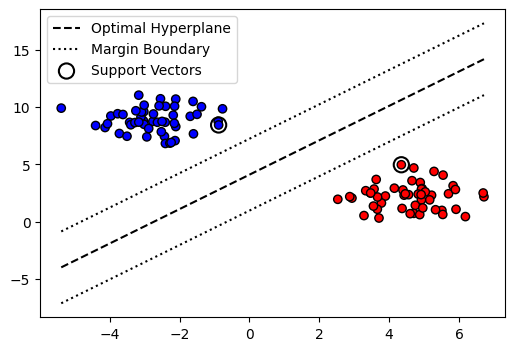

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(X[:,0], X[:,1], c=Y, cmap='bwr', edgecolor='black')

plt.plot(x_vals, y_vals, 'k--', label='Optimal Hyperplane')
plt.plot(x_vals, y_margin_pos, 'k:', label='Margin Boundary')
plt.plot(x_vals, y_margin_neg, 'k:')

plt.scatter(
    svm.support_vectors_[:,0],
    svm.support_vectors_[:,1],
    facecolor='none',
    s=120,
    edgecolors='black',
    linewidth=1.5,
    label='Support Vectors'
)
plt.legend()

In [69]:
print('Weight vector w: ',w)
print('Bias b: ',b[0])
print('Margin (1/||w||): ',margin)
print('Support vectors: ',len(svm.support_vectors_))

Weight vector w:  [ 0.26506647 -0.17623745]
Bias b:  0.7223721957923663
Margin (1/||w||):  3.141612960382368
Support vectors:  2


In [48]:
svm.support_vectors_

array([[-0.88351417,  8.44418889],
       [ 4.34875632,  4.96535577]])